In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv(r'..\data\final_features.csv')

In [3]:
df.head()

,Login Successful,Is Attack IP,Is Account Takeover,is_night_login,is_high_risk_country,is_bot_browser,is_attack_asn,Device Type_bot,Device Type_desktop,Device Type_mobile,Device Type_tablet,Device Type_unknown
0,True,False,False,0,0,0,0,False,False,True,False,False
1,True,False,False,1,0,0,0,False,False,True,False,False
2,False,False,False,0,0,0,0,False,False,True,False,False
3,True,False,False,0,0,0,0,False,False,True,False,False
4,False,False,False,0,0,0,0,False,False,True,False,False


In [4]:
X = df.drop(columns=['Is Account Takeover', 'Is Attack IP', 'Login Successful'])
y = df['Is Account Takeover']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Training complete")

Training complete


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
y_pred = model.predict(X_test)

print("Classification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     18896
        True       0.95      0.64      0.76        33

    accuracy                           1.00     18929
   macro avg       0.98      0.82      0.88     18929
weighted avg       1.00      1.00      1.00     18929

Confusion matrix:
[[18895     1]
 [   12    21]]


In [11]:
import matplotlib.pyplot as plt
import numpy as np

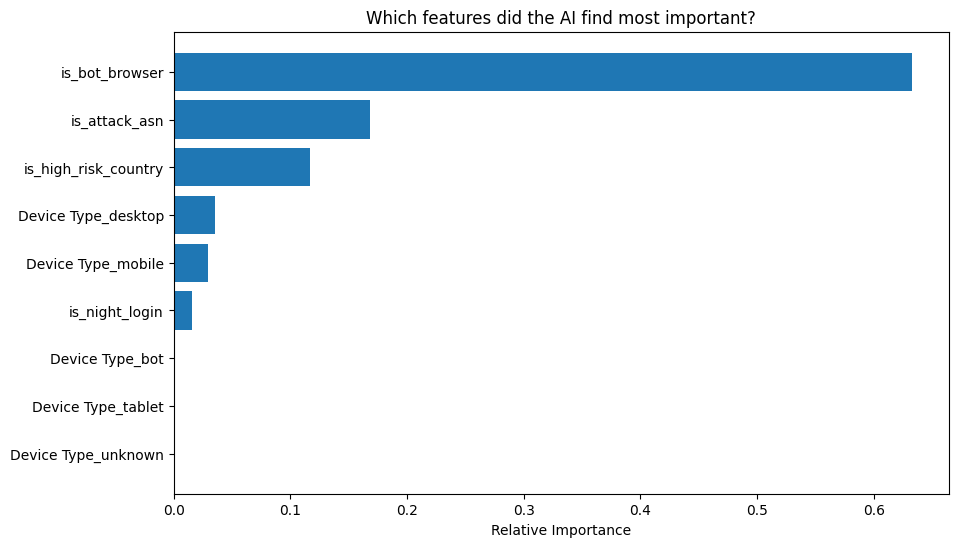

In [12]:
importances = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Which features did the AI find most important?")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [13]:
import joblib

In [14]:
joblib.dump(model, 'account_takeover_detector.joblib')

model_features = X.columns.tolist()
joblib.dump(model_features, 'model_features.joblib')

print("Model saved successfully")

Model saved successfully
